In [1]:
!pip install kagglehub pandas numpy matplotlib seaborn plotly

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [3]:
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [4]:
df = pd.read_csv(f"{path}/netflix_titles.csv")

Dataset Overview

In [5]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [6]:
df.shape

(8807, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Handling Missing Value

In [9]:
#finding unique values in all column where we have large number of missing samples
print(df["director"].nunique())
print(df["country"].nunique())
print(df["cast"].nunique())

4528
748
7692


In [10]:
#cleaning date column
df["date_added"]=df["date_added"].str.strip()
df["date_added"]=pd.to_datetime(df["date_added"])
median_date=df["date_added"].median()
df["date_added"]=df["date_added"].fillna(median_date)

In [11]:
#filling NaN ratings
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

In [12]:
#filling NaN duration
df["duration"]=df["duration"].fillna(df["duration"].mode()[0])

Feature Engineering

In [13]:
df["tv_seasons"]=np.where(
    df["type"]=="TV Show",
    df["duration"].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)
df["movie_duration"] = np.where(
    df["type"] == "Movie",
    df["duration"].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)

In [14]:
df[["movie_duration","tv_seasons"]].head()

,movie_duration,tv_seasons
0,90.0,NaN
1,NaN,2.0
2,NaN,1.0
3,NaN,1.0
4,NaN,2.0


In [15]:
#unnesting multi value columns
country_df = df.copy()
country_df["country"] = country_df["country"].str.split(",")
country_df = country_df.explode("country")
country_df["country"] = country_df["country"].str.strip()


director_df = df.copy()
director_df["director"] = director_df["director"].str.split(",")
director_df = director_df.explode("director")
director_df["director"] = director_df["director"].str.strip()
cast_df = df.copy()


cast_df["cast"] = cast_df["cast"].str.split(",")
cast_df = cast_df.explode("cast")
cast_df["cast"] = cast_df["cast"].str.strip()
genre_df = df.copy()


genre_df["listed_in"] = genre_df["listed_in"].str.split(",")
genre_df = genre_df.explode("listed_in")
genre_df["listed_in"] = genre_df["listed_in"].str.strip()

Temporal Trends

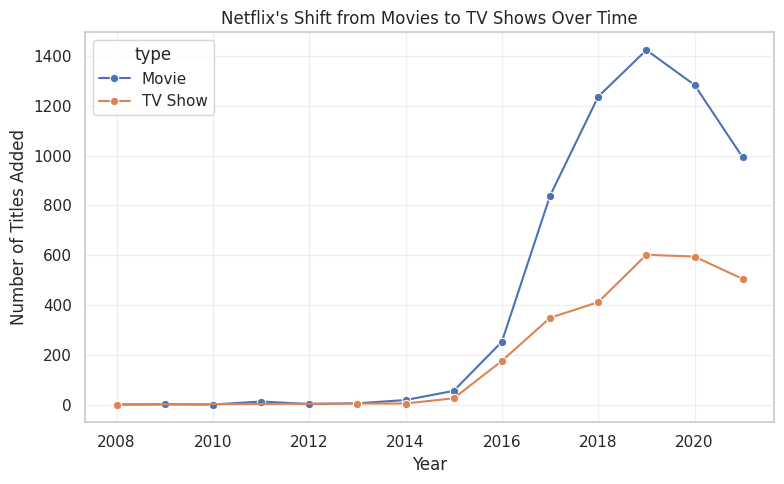

In [16]:
df["year"]=df["date_added"].dt.year
yearly_type = (
    df.groupby(["year", "type"])
      .size()
      .reset_index(name="count")
)
plt.figure(figsize=(8,5))
sns.lineplot(
    data=yearly_type,
    x="year",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Netflix's Shift from Movies to TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(alpha=0.3)

plt.tight_layout()


plt.show()
#result Before 2015, both Movies and TV Shows were added in relatively small numbers. From 2016 onward, Netflix significantly increased the addition of both content types, with TV Shows experiencing rapid growth. Although Movies continued to dominate in terms of the number of titles added, the sharp rise in TV Shows suggests that Netflix increasingly invested in episodic content over time.

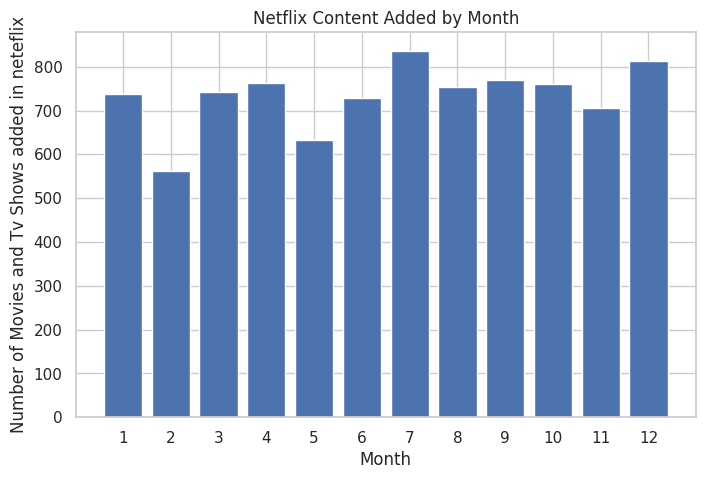

In [17]:
x=df["date_added"].dt.month.value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(x.index,x.values)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Movies and Tv Shows added in neteflix")

plt.xticks(range(1,13))

plt.show()
#result July is the most popular month for new releases.

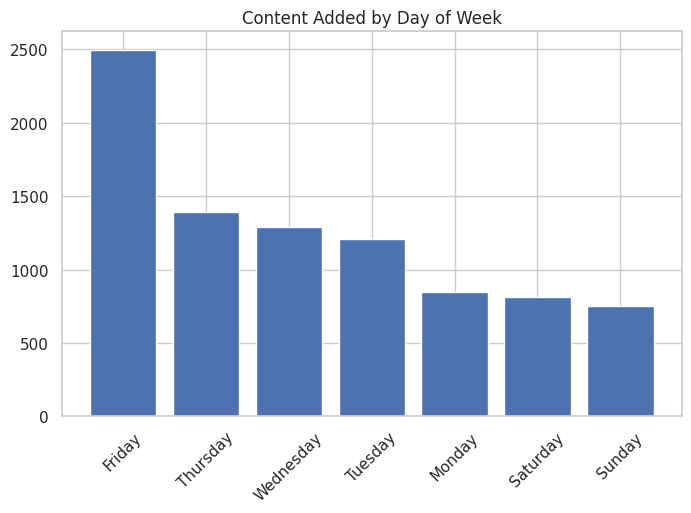

In [18]:
weekday = df["date_added"].dt.day_name().value_counts()

plt.figure(figsize=(8,5))
plt.bar(
    weekday.index,
    weekday.values
)

plt.xticks(rotation=45)

plt.title("Content Added by Day of Week")

plt.show()
#result-> Friday is the best day to add or release new content because it is followed by weekends so most user come online and spent their time by watching latest contents.

<Axes: xlabel='movie_duration', ylabel='Count'>

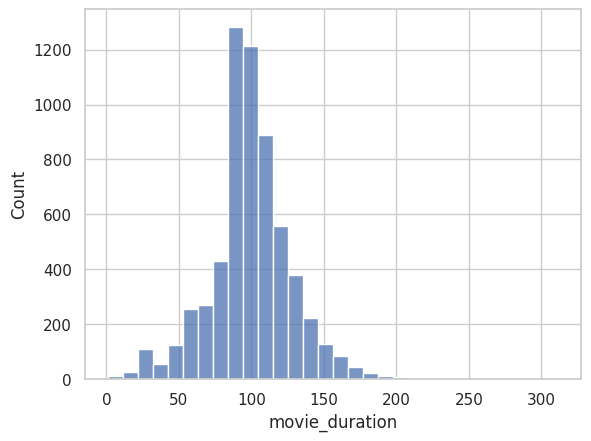

In [19]:
sns.histplot(
    df["movie_duration"],
    bins=30
)
#result-> most of the show have duration around 90 to 110 minutes.

<Axes: xlabel='count', ylabel='rating'>

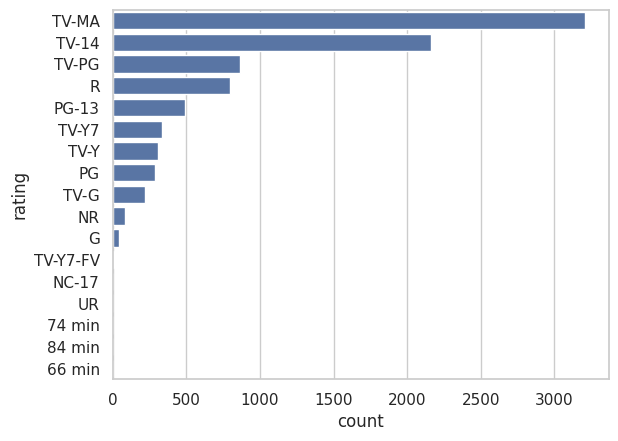

In [20]:
sns.countplot(
    y=df["rating"],
    order=df["rating"].value_counts().index
)
#result-> Most of the user give rating of TV-MA followed by TV-14 and TV-PG

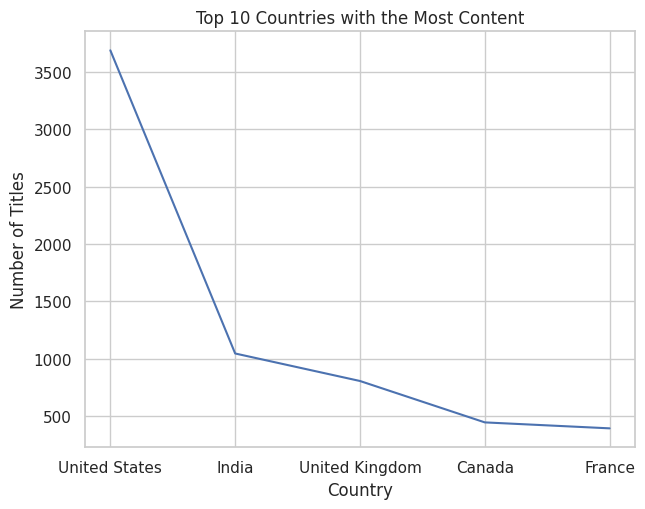

In [21]:
plt.plot(country_df["country"].value_counts().head(5))
plt.tight_layout()
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.title("Top 10 Countries with the Most Content")
plt.show()
#result-> USA releases the highest number of shows on netflix,india releases 1/3rd of highest value produced

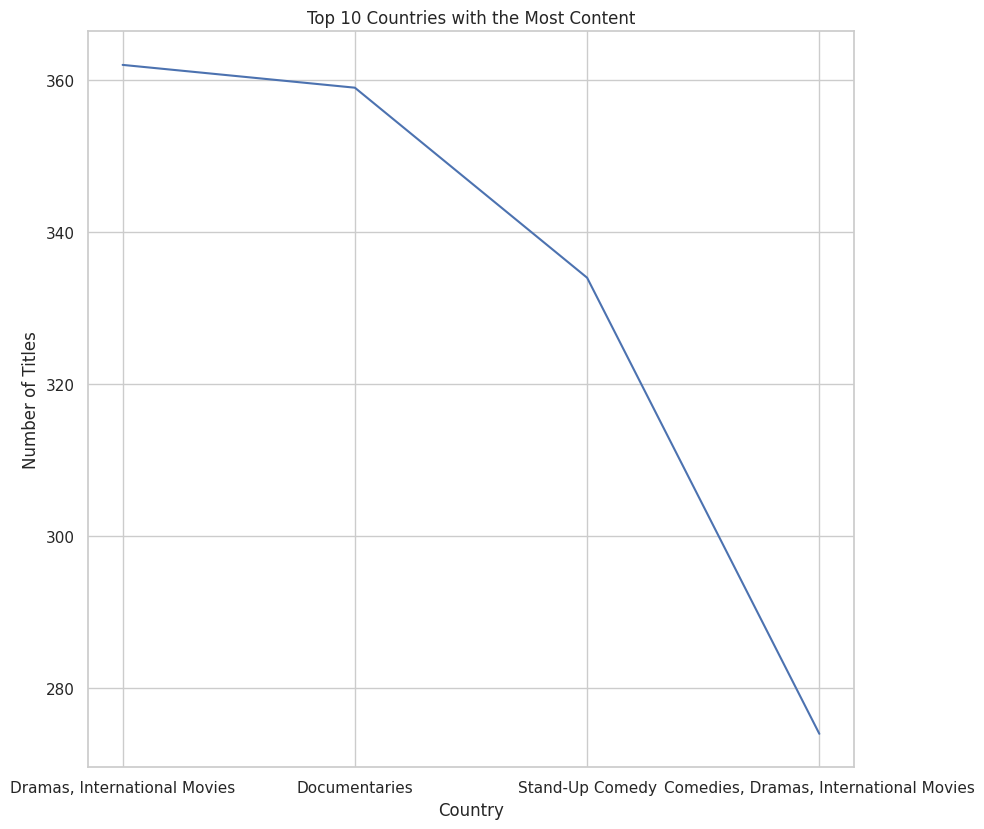

In [22]:
plt.figure(figsize=(10,8))
plt.plot(df["listed_in"].value_counts().head(4))
plt.tight_layout()
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.title("Top 10 Countries with the Most Content")
plt.show()
#top genres are Dramas,International Moies,Documentaries,"Stand-up Comedy"

Country Collaboration Analysis

In [23]:
from itertools import combinations

collab_dict = {}

# Loop through each movie/show
for countries in df["country"].dropna():

    # Split and remove extra spaces
    country_list = [c.strip() for c in countries.split(",")]

    # Skip titles with only one country
    if len(country_list) < 2:
        continue

    # Generate all country pairs
    for pair in combinations(country_list, 2):

        # Store every pair in alphabetical order
        pair = tuple(sorted(pair))

        # Update dictionary
        if pair in collab_dict:
            collab_dict[pair] += 1
        else:
            collab_dict[pair] = 1

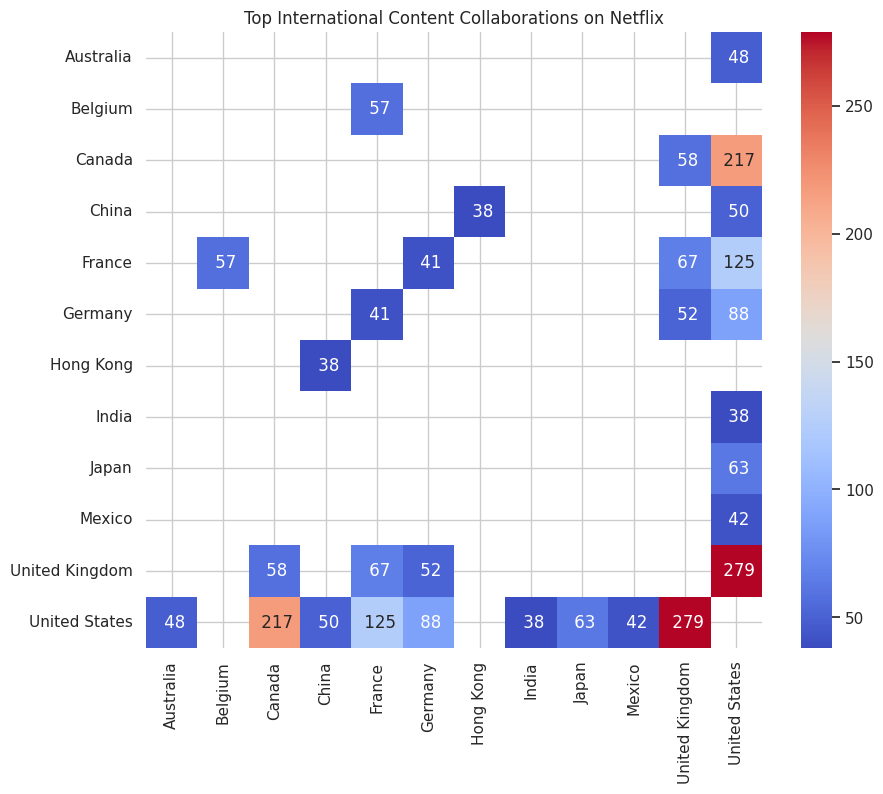

In [24]:


collab_df = pd.DataFrame(
    [(c1, c2, count) for (c1, c2), count in collab_dict.items()],
    columns=["Country1", "Country2", "Count"]
)
top_collab = collab_df.sort_values(
    by="Count",
    ascending=False
).head(15)
heatmap_df = top_collab.pivot(
    index="Country1",
    columns="Country2",
    values="Count"
)
heatmap_df = heatmap_df.combine_first(heatmap_df.T)
plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=" .0f",
    cmap="coolwarm",
    square=True
)

plt.title("Top International Content Collaborations on Netflix")

plt.show()
#result-> The heatmap highlights the strongest international co-production partnerships on Netflix. Darker cells indicate more frequent collaborations. The United States collaborate highest with the United Kingdom and also with several countries.

Actor & Director Analytics

In [25]:

duo_dict = {}
# Loop through row
for row in df.itertuples():
  # Skip rows with missing director or cast
    if pd.isna(row.director) or pd.isna(row.cast):
        continue
  # Split and remove extra spaces
    director_list = [d.strip() for d in row.director.split(",")]
    # Split and remove extra spaces
    cast_list = [c.strip() for c in row.cast.split(",")]
    # Generate all duo

    for i in director_list:
      for j in cast_list:
        pair=(i,j)


        # Update dictionary
        if pair in duo_dict:
            duo_dict[pair] += 1
        else:
            duo_dict[pair] = 1

/tmp/ipykernel_8869/468121746.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10["Duo"] = top10["Director"] + " -> " + top10["Actor"]


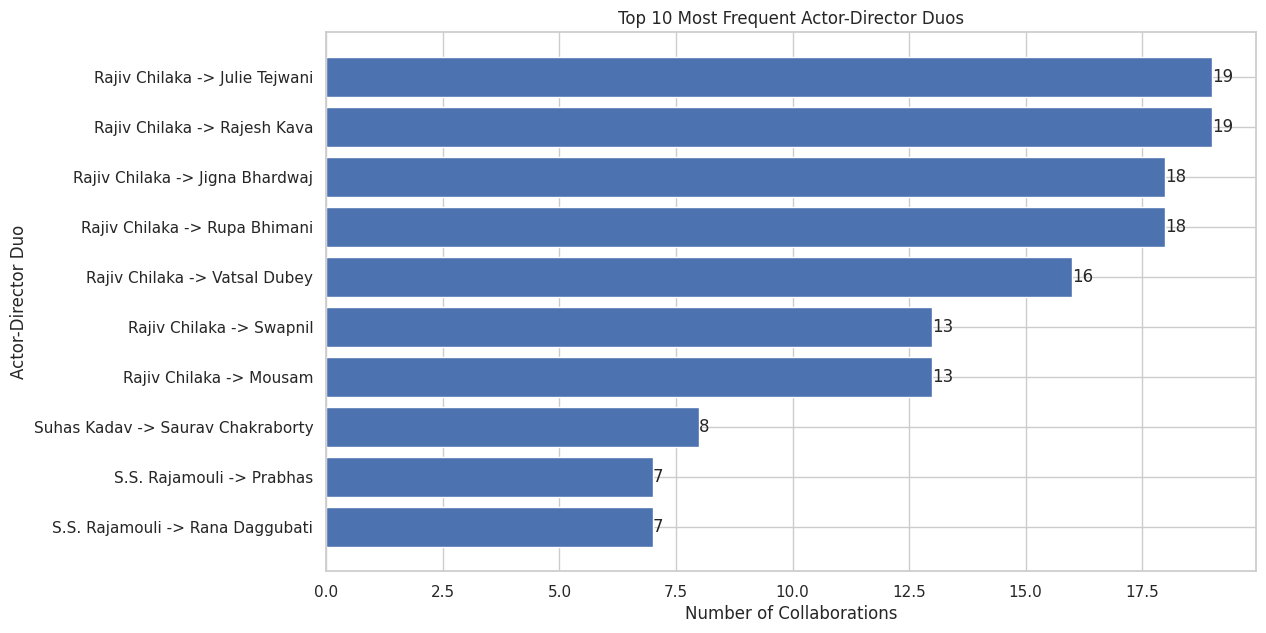

In [26]:
duo_df = pd.DataFrame(
    [(director, actor, count) for (director, actor), count in duo_dict.items()],
    columns=["Director", "Actor", "Count"]
)
duo_df = duo_df.sort_values(by="Count", ascending=False).head(10)
top10 = duo_df.head(10)

top10["Duo"] = top10["Director"] + " -> " + top10["Actor"]

plt.figure(figsize=(12,7))

bars = plt.barh(
    top10["Duo"],
    top10["Count"]
)

plt.bar_label(bars, fmt='%d')

plt.xlabel("Number of Collaborations")
plt.ylabel("Actor-Director Duo")
plt.title("Top 10 Most Frequent Actor-Director Duos")

plt.gca().invert_yaxis()   # Highest collaboration at the top

plt.show()
#result -> the top director and actor duo is Rajiv Chilaka and juile Tejwani, and Rajiv Chilaka and Rajesh Kava they have made a total of 19 films together. Also Rajiv Chilaka could be the best director because he has made collaboration with a lot of

Genre Analysis

<Axes: xlabel='cast'>

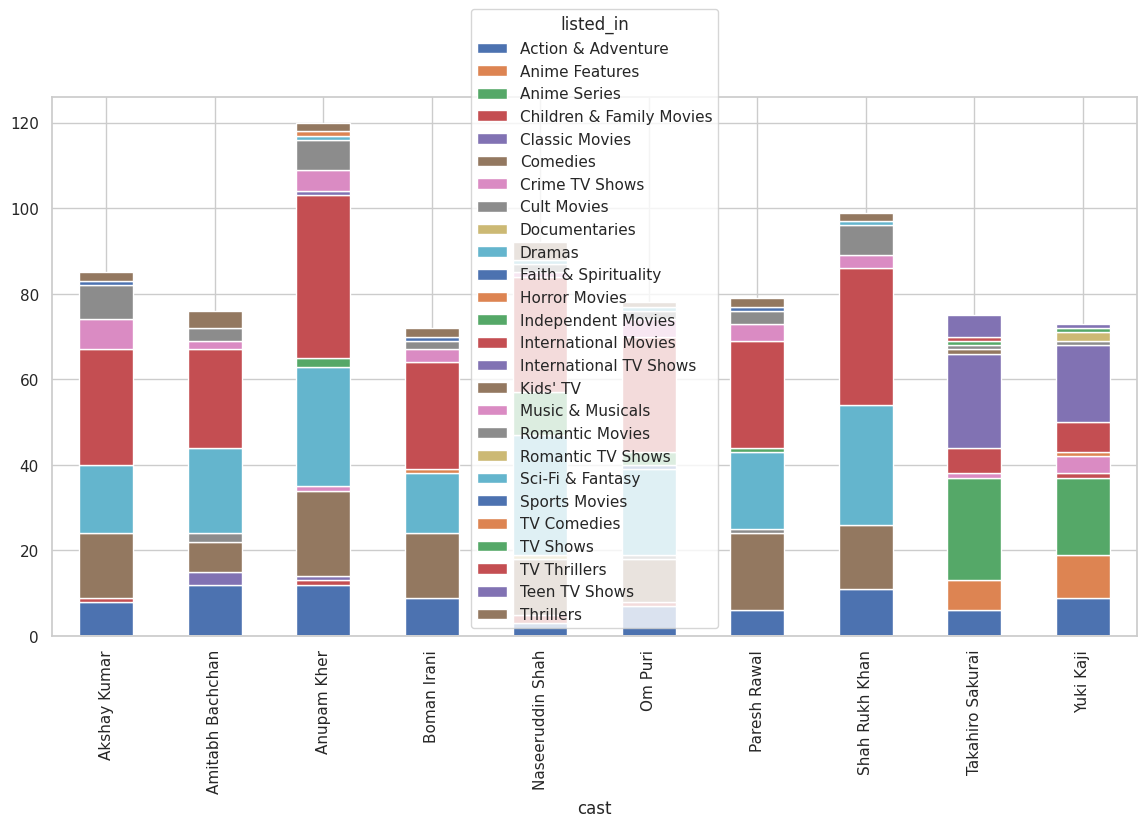

In [27]:
actor_genre_df = df.copy()
actor_genre_df["cast"] = actor_genre_df["cast"].str.split(",")
actor_genre_df["listed_in"] =actor_genre_df["listed_in"].str.split(",")
actor_genre_df = actor_genre_df.explode("cast")
actor_genre_df = actor_genre_df.explode("listed_in")
actor_genre_df["cast"] = actor_genre_df["cast"].str.strip()
actor_genre_df["listed_in"] = actor_genre_df["listed_in"].str.strip()
x=actor_genre_df["cast"].value_counts()
top_10=x.head(10)
top_actor=actor_genre_df[actor_genre_df["cast"].isin(top_10.index)]
genre_distribution = (
    top_actor
    .groupby(["cast", "listed_in"])
    .size()
    .reset_index(name="Count")
)
pivot_df = genre_distribution.pivot(
    index="cast",
    columns="listed_in",
    values="Count"
).fillna(0)
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)


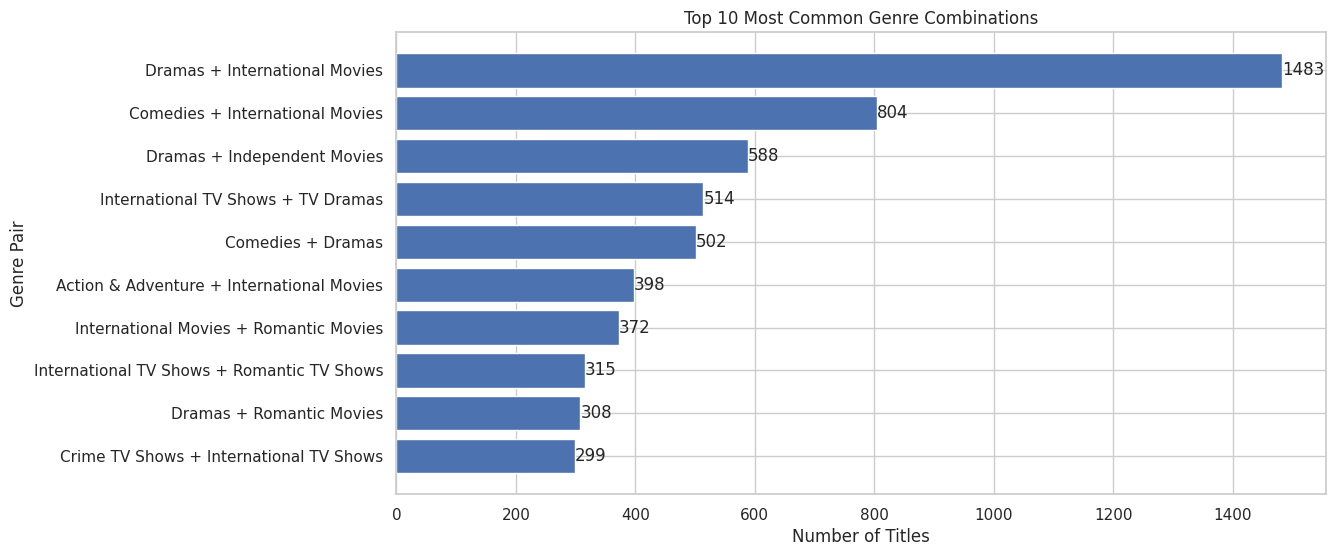

In [28]:
from itertools import combinations

genre_pair_dict = {}

# Loop through each genre
for genre in df["listed_in"].dropna():

    # Split and remove extra spaces
    genre_list = [c.strip() for c in genre.split(",")]

    # Skip titles with only one genre
    if len(genre_list) < 2:
        continue

    # Generate all genre pairs
    for pair in combinations(genre_list, 2):

        # Store every pair in alphabetical order
        pair = tuple(sorted(pair))

        # Update dictionary
        if pair in genre_pair_dict:
            genre_pair_dict[pair] += 1
        else:
            genre_pair_dict[pair] = 1
genre_df = pd.DataFrame(
    [(c1, c2, count) for (c1, c2), count in genre_pair_dict.items()],
    columns=["genre1", "genre2", "Count"]
)
top_genre = genre_df.sort_values(
    by="Count",
    ascending=False
).head(10)
top_genre["Genre Pair"] = (
    top_genre["genre1"] +
    " + " +
    top_genre["genre2"]
)
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_genre["Genre Pair"],
    top_genre["Count"]
)

plt.bar_label(bars)

plt.xlabel("Number of Titles")
plt.ylabel("Genre Pair")
plt.title("Top 10 Most Common Genre Combinations")

plt.gca().invert_yaxis()

plt.show()

Text Analysis

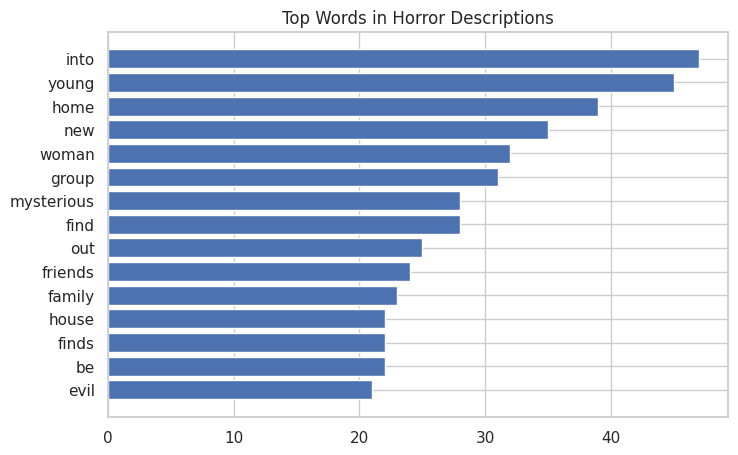

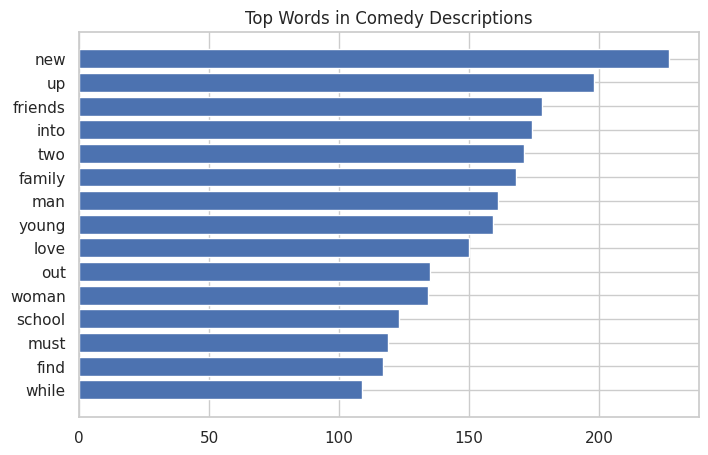

In [29]:
import re
from collections import Counter
import matplotlib.pyplot as plt

def top_words(genre):
    text = " ".join(
        df[df["listed_in"].str.contains(genre, case=False, na=False)]["description"]
    ).lower()

    text = re.sub(r'[^a-z\s]', '', text)

    stop_words = {"when","the","a","an","and","of","to","in","is","on","for","with","this","that","his","her","their","was","were","after","but","who","by","as","from","at","he","him","they","see","i","we","you","she","them","are","movie","film","story","life","based","life"}

    words = [w for w in text.split() if w not in stop_words]

    return Counter(words).most_common(15)

horror = pd.DataFrame(top_words("Horror Movies"), columns=["Word","Count"])

plt.figure(figsize=(8,5))
plt.barh(horror["Word"], horror["Count"])
plt.gca().invert_yaxis()
plt.title("Top Words in Horror Descriptions")
plt.show()
comedy = pd.DataFrame(top_words("Comedies"), columns=["Word","Count"])

plt.figure(figsize=(8,5))
plt.barh(comedy["Word"], comedy["Count"])
plt.gca().invert_yaxis()
plt.title("Top Words in Comedy Descriptions")
plt.show()

Conclusion


• Netflix rapidly expanded its content library after 2016.

• Movies remain more numerous than TV Shows, but TV Shows have grown much faster.

• International Movies frequently appear alongside Drama and Comedy.

• The United States collaborates extensively with several countries.

• Top actors are associated with diverse genre distributions.

• Horror descriptions emphasize suspense-related words, whereas Comedy descriptions emphasize family, friendship, and humor.